In [1]:
# this is the part of the numerical transformation only 

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import scipy.stats as stats

In [8]:
df = pd.read_csv('concrete_data.csv') # ye data set because its not at all normal

In [6]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [9]:
# we have to predict strenght from given features 

In [10]:
df.shape

(1030, 9)

In [12]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [16]:
df.describe() # minimum value 0 hai, and for box-cox the minimum should be grater than 0

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [17]:
x = df.drop(columns = ['Strength'])

In [18]:
y = df.iloc[:, -1]

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [20]:
from sklearn.model_selection import train_test_split

In [22]:
from sklearn.linear_model import LinearRegression

<Axes: xlabel='Cement', ylabel='Count'>

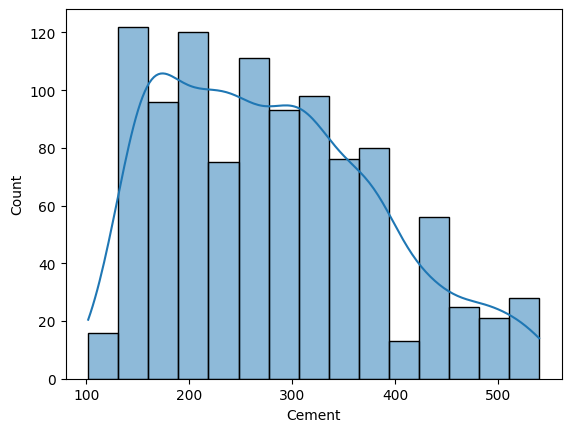

In [25]:
sns.histplot(df['Cement'], kde = True)

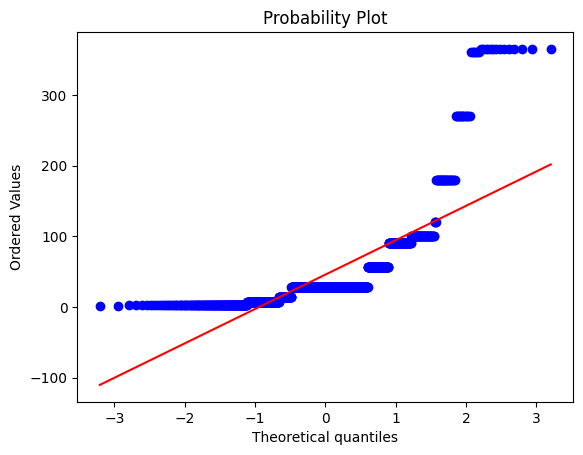

In [26]:
stats.probplot(df['Age'], dist="norm", plot=plt)
plt.show()

<Axes: xlabel='Blast Furnace Slag', ylabel='Count'>

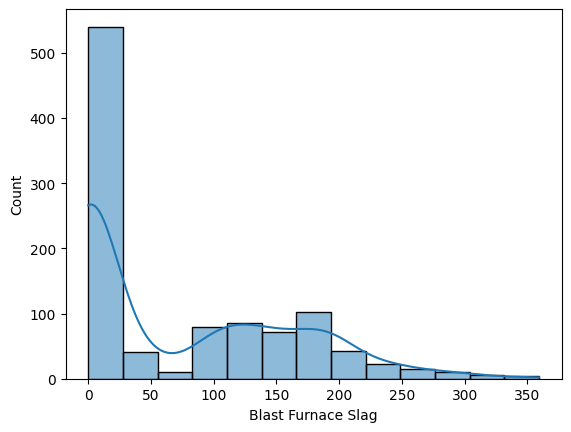

In [27]:
sns.histplot(df['Blast Furnace Slag'], kde = True)

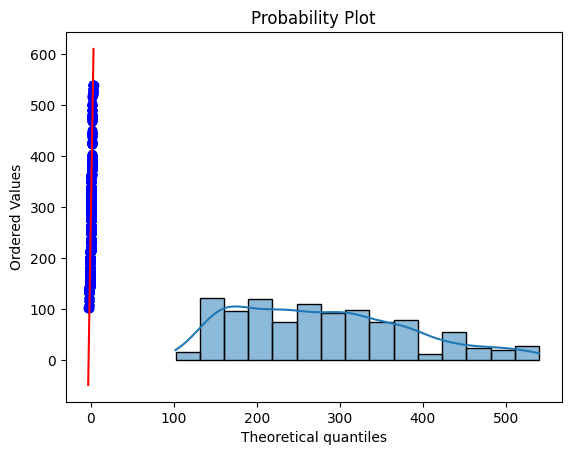

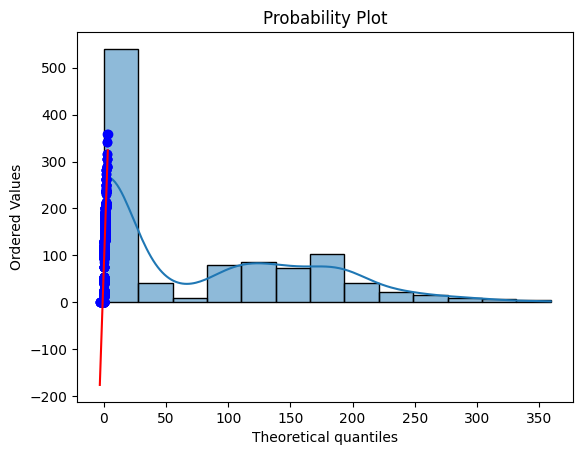

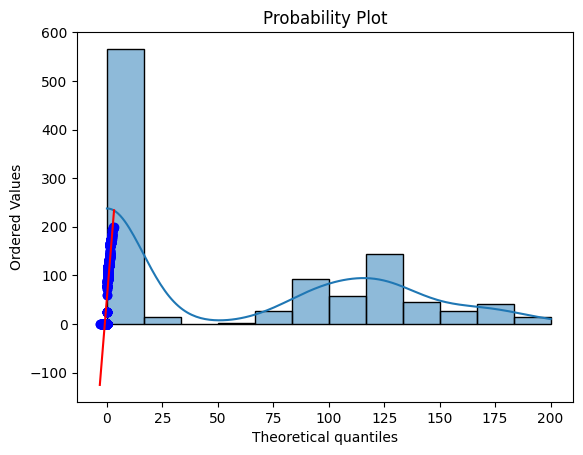

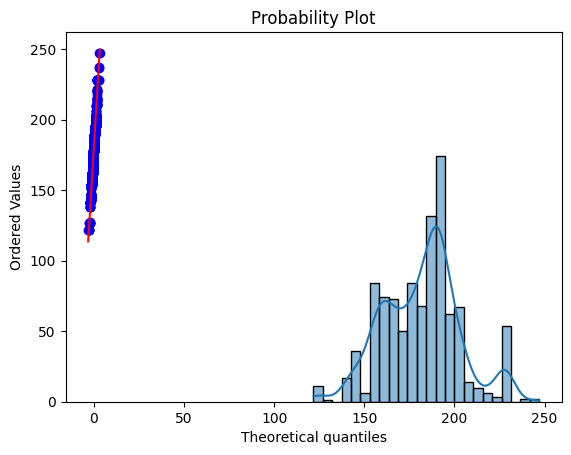

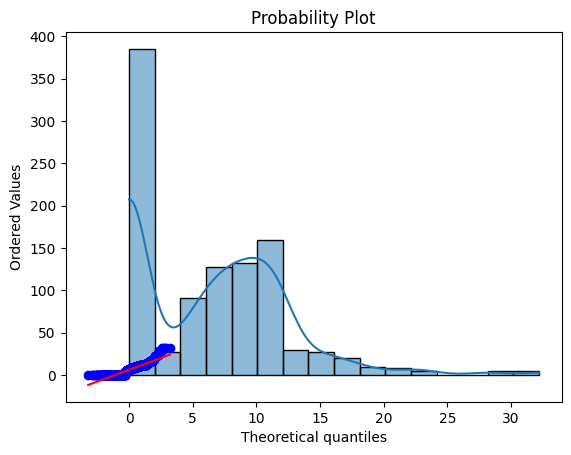

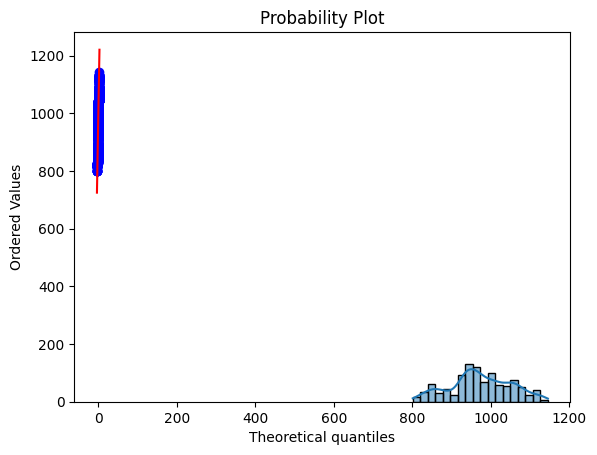

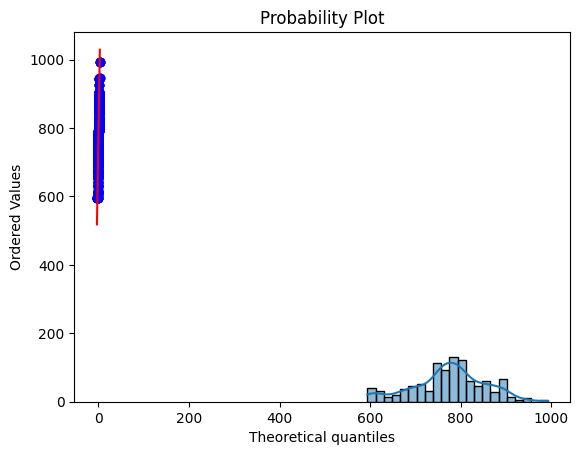

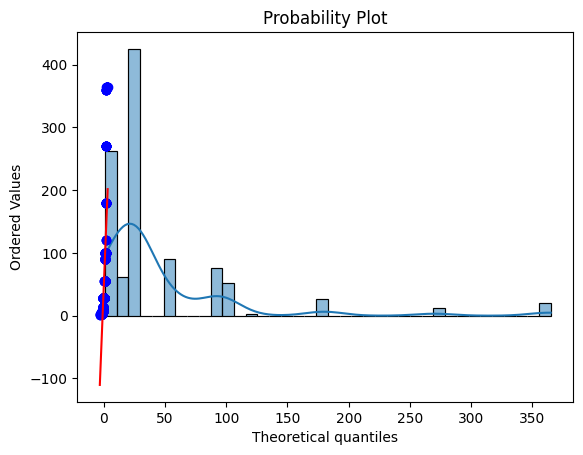

In [31]:
for cols in x_train.columns:
    sns.histplot(df[cols], kde = True)
    stats.probplot(df[cols], dist="norm", plot=plt)
    plt.show()

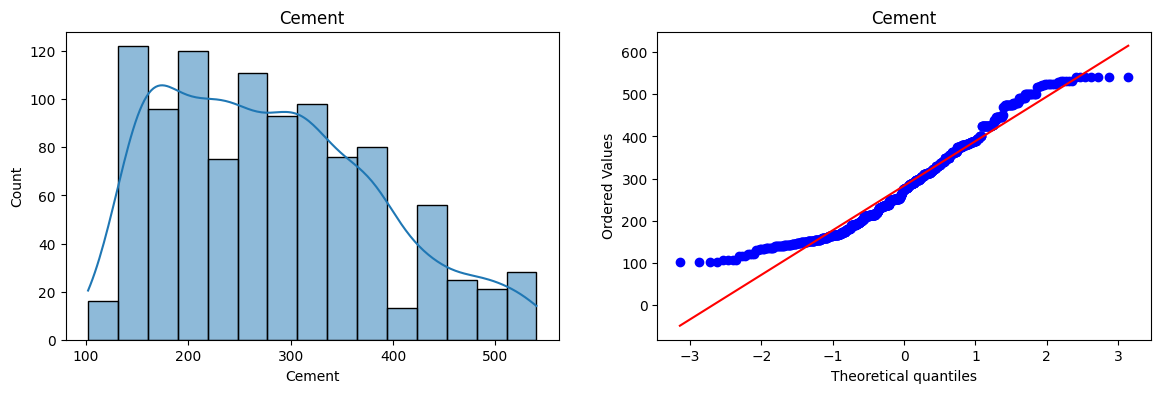

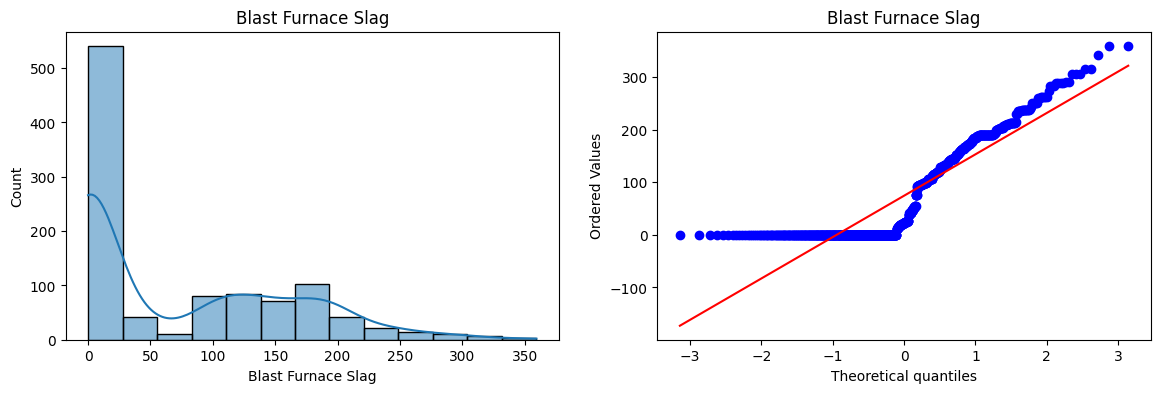

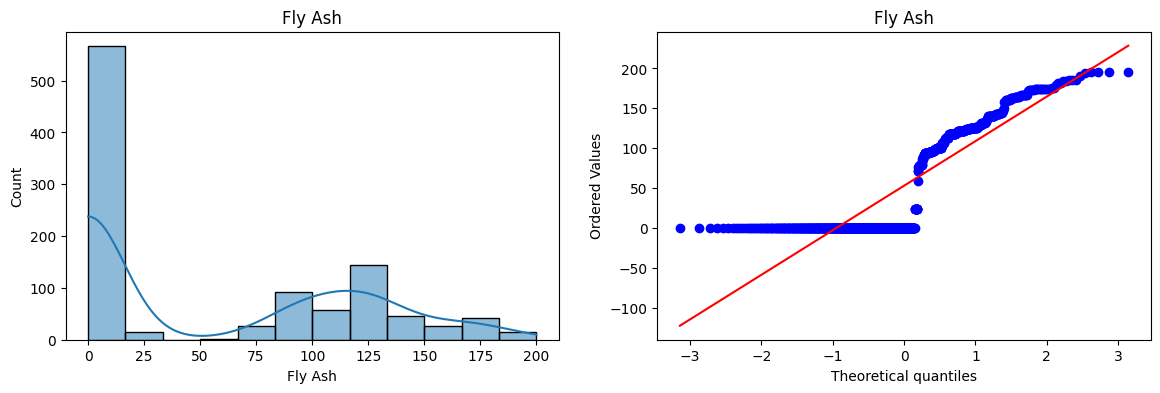

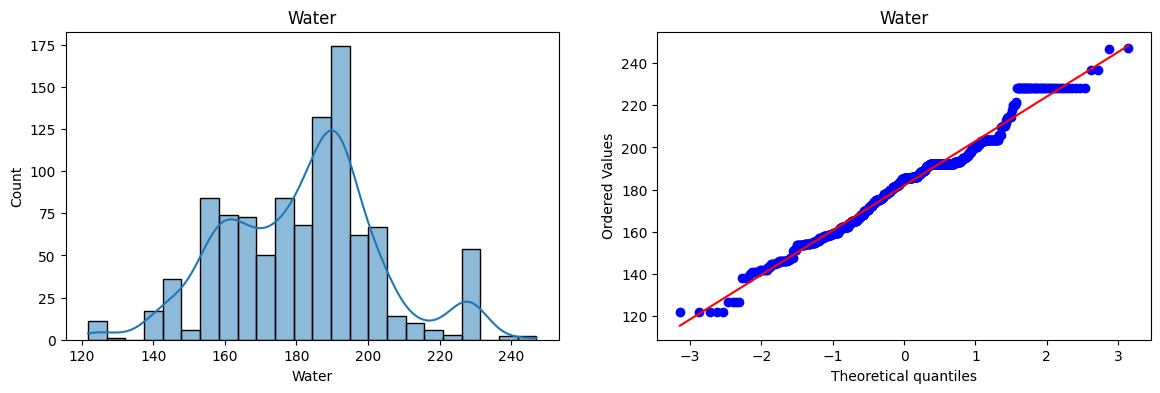

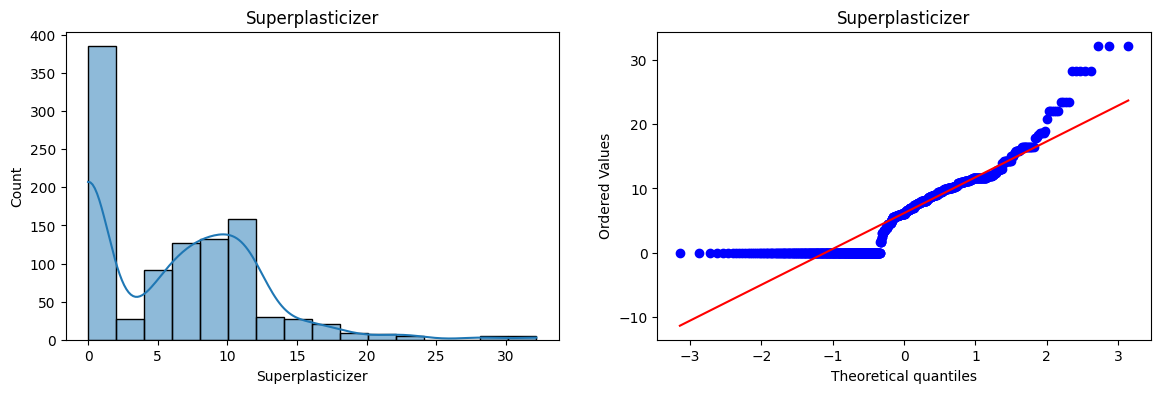

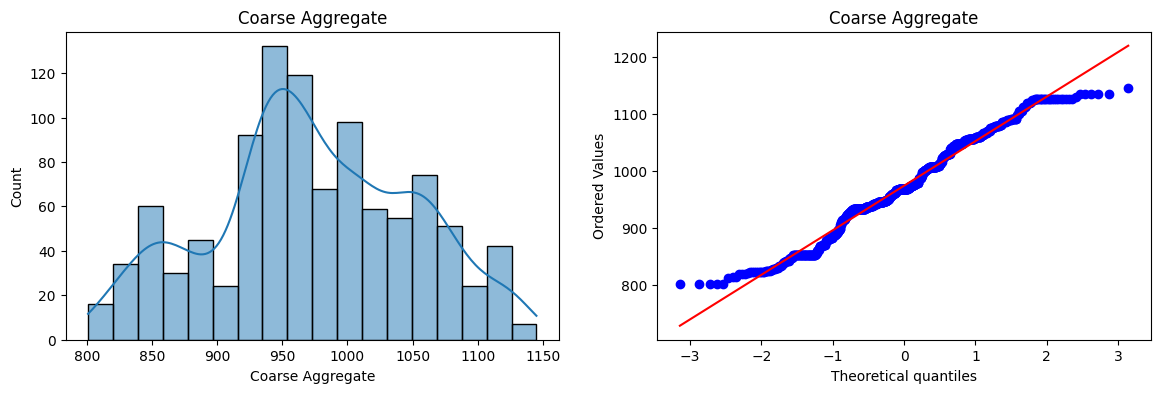

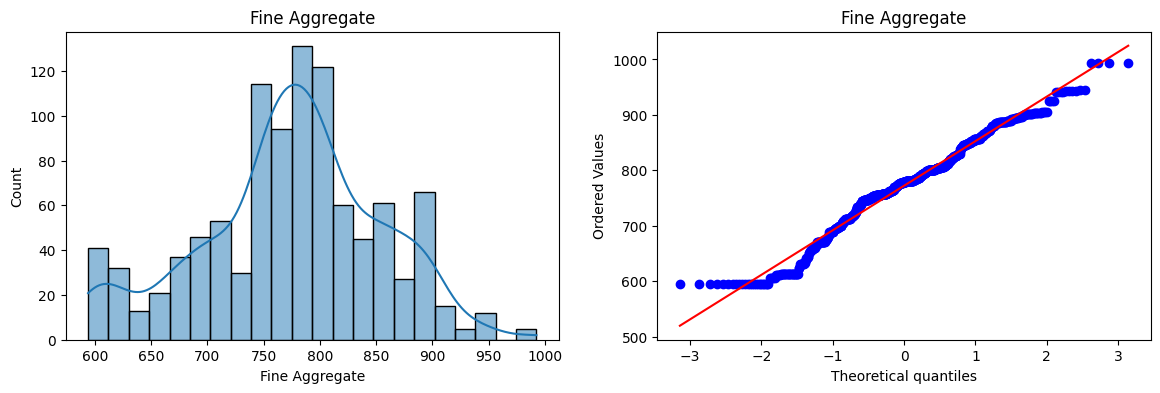

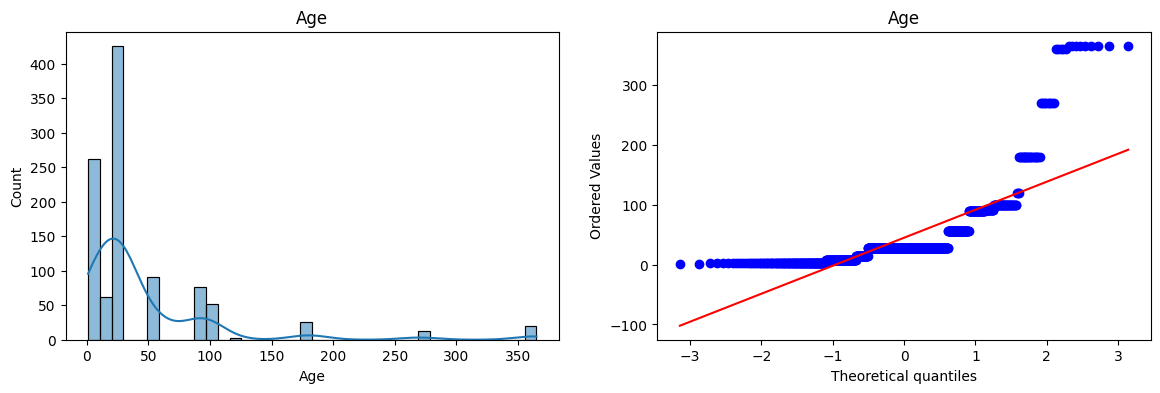

In [37]:
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(df[col], kde = True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [38]:
# age ka distribution is so badddddd

In [39]:
from sklearn.preprocessing import PowerTransformer

In [40]:
pt = PowerTransformer(method = 'box-cox')

In [41]:
x_train_transformed = pt.fit_transform(x_train)

ValueError: The Box-Cox transformation can only be applied to strictly positive data

In [46]:
x_train_transformed = pt.fit_transform((x_train + 0.00001))

In [47]:
x_test_transformed = pt.fit_transform((x_test + 0.00001))

In [49]:
for col, lam in zip(x_train.columns, pt.lambdas_):
    print(f"{col}: {lam}")

Cement: 0.2156021444903458
Blast Furnace Slag: 0.028898630300654763
Fly Ash: -0.007561072719937325
Water: 0.9590618568647188
Superplasticizer: 0.11939768065583883
Coarse Aggregate: 1.192491387860447
Fine Aggregate: 1.9737810906822193
Age: -0.014692152809921139


In [51]:
pd.DataFrame({'cols': x_train.columns , 'box_cox_lambdas': pt.lambdas_}) 

,cols,box_cox_lambdas
0,Cement,0.215602
1,Blast Furnace Slag,0.028899
2,Fly Ash,-0.007561
3,Water,0.959062
4,Superplasticizer,0.119398
5,Coarse Aggregate,1.192491
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [57]:
lr = LinearRegression()

In [59]:
lr.fit(x_train_transformed,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred = lr.predict(x_test_transformed)

In [61]:
y_pred

array([50.27834276, 47.19643829, 65.62117622, 40.19766139, 15.16602807,
       45.38721201, 27.51351864, 48.24394686, 30.74108251, 46.3820032 ,
       40.47254597, 16.42909842, 53.05351402, 42.39055878, 29.48754087,
       25.45414515, 34.01097697, 22.19954419, 39.70767627, 28.09141701,
       38.84824461, 26.4842111 , 42.87739503,  6.47055619, 37.19061565,
       35.57475504, 11.50434247, 52.1061922 , 44.44225509, 13.68878041,
       42.05799205, 37.07067487, 40.10529933, 50.32243955, 15.60763549,
       37.23028509, 30.50893699, 45.2272486 ,  7.98147099, 44.4168039 ,
       19.09240936, -3.22769439, 36.60556829, 55.60676108,  8.66218948,
       63.59076679, 51.21007635, 49.86520098, 26.62057179,  1.52392381,
       48.83404266, 42.77564931, 26.59258242, 18.62730758, 42.96833497,
       39.78034479, 25.13739403, 14.57370526, 34.21669629, 25.70322179,
       45.12339998, 14.09773881, 37.06941767, 53.50393868, 28.20812654,
       24.66023925, 38.6252317 , 20.06424415, 30.67509667, 25.42

In [62]:
# we use accuracy score for classification vale problems and we use r2_score for regression vale problems 

In [66]:
r2_score(y_test,y_pred)

0.8061415974444238

In [65]:
from sklearn.metrics import r2_score

In [67]:
from sklearn.model_selection import cross_val_score

In [69]:
np.mean(cross_val_score(lr,x_train_transformed,y,scoring='r2'))

ValueError: Found input variables with inconsistent numbers of samples: [824, 1030]

In [71]:
pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(x+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537941434355)

In [74]:
for col in x_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(x_train_transformed[col])
    plt.title(col)

    plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [77]:
X_train_transformed = pd.DataFrame(x_train_transformed,columns=x_train.columns)

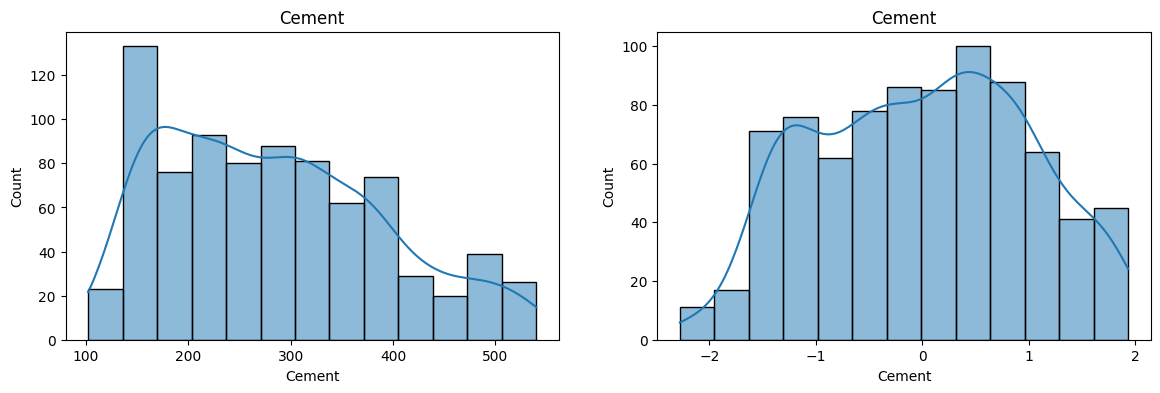

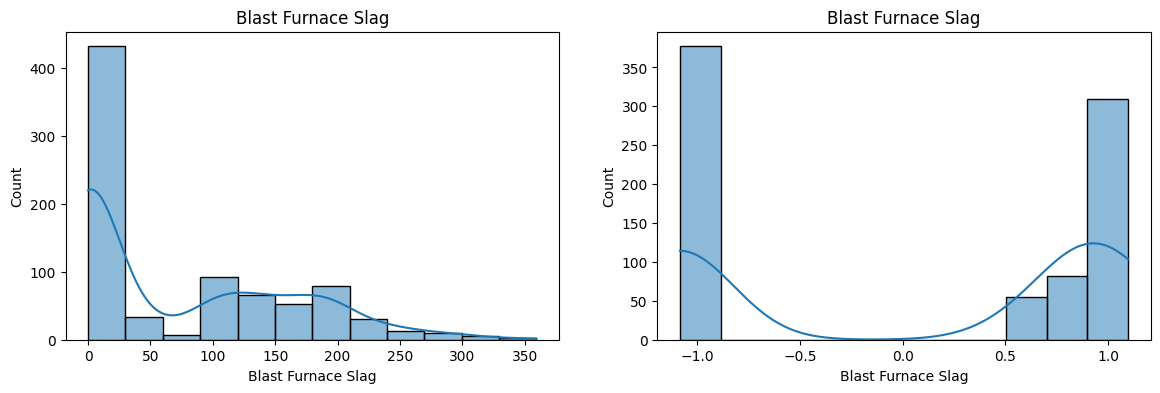

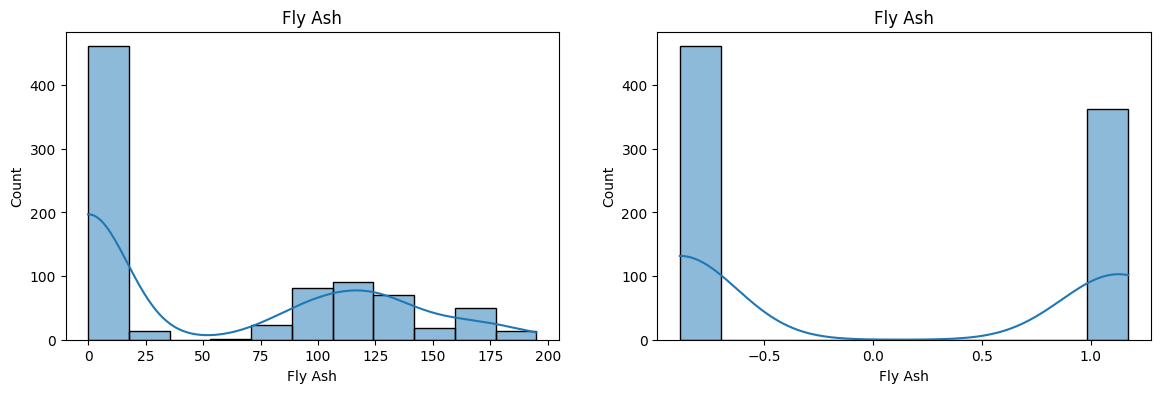

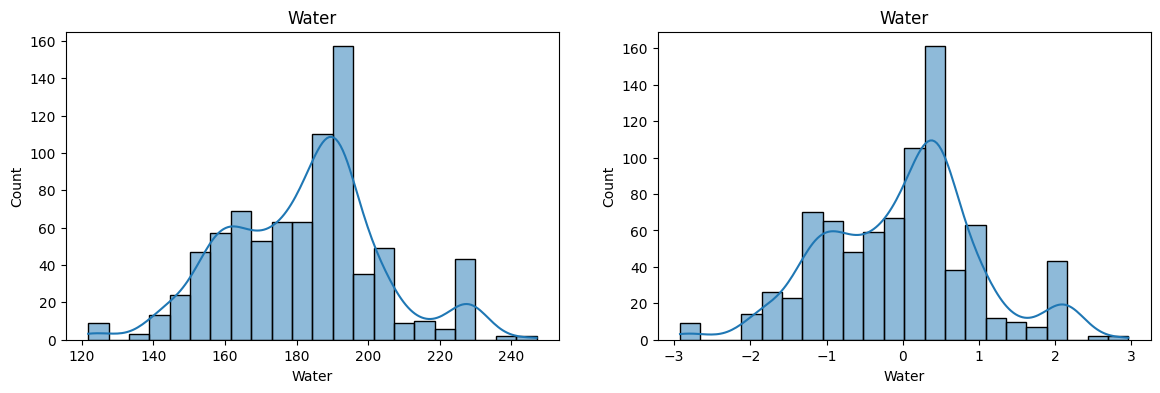

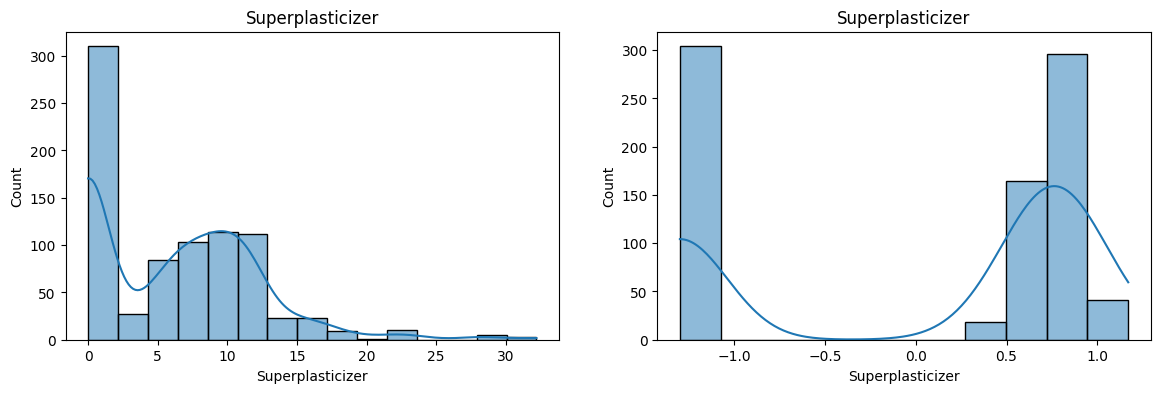

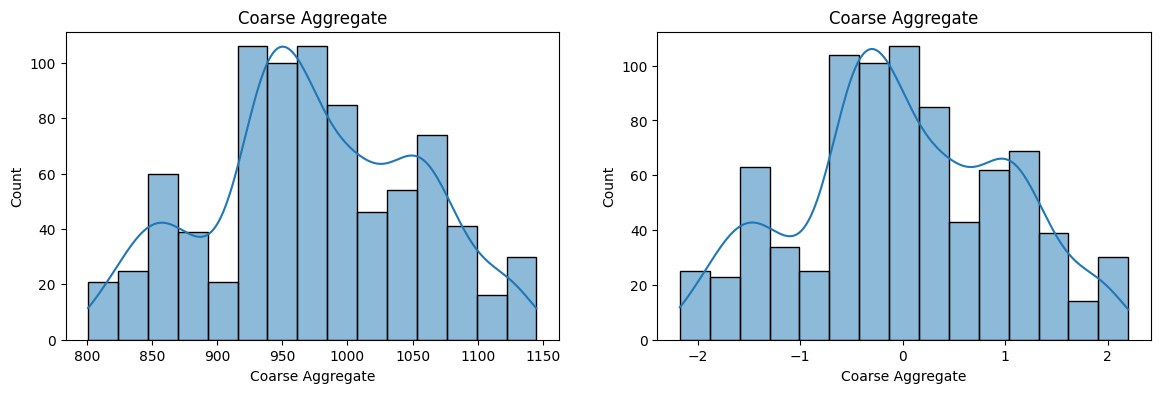

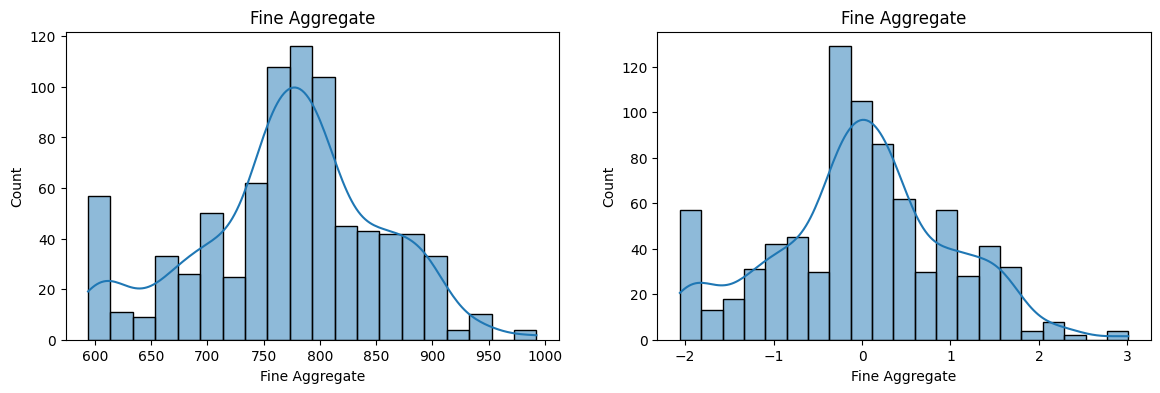

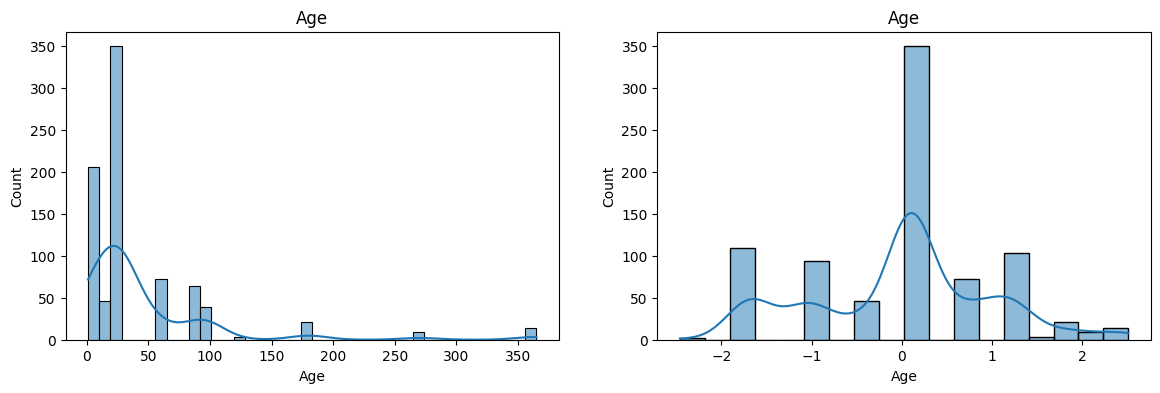

In [80]:
for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col], kde = True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde = True)
    plt.title(col)

    plt.show()

In [81]:
pt1 = PowerTransformer() # by default it has yeo - johnson only

In [82]:
x_train_transformed2 = pt1.fit_transform(x_train)

In [83]:
x_test_transformed2 = pt1.fit_transform(x_test)

In [87]:
lr.fit(x_train_transformed2, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
y_pred2 = lr.predict(x_test_transformed2)

In [89]:
r2_score(y_test, y_pred)

0.8061415974444238

In [91]:
pt = PowerTransformer()
X_transformed = pt.fit_transform(x)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6834625126992434)

In [93]:
X_train_transformed2 = pd.DataFrame(x_train_transformed2,columns=x_train.columns)

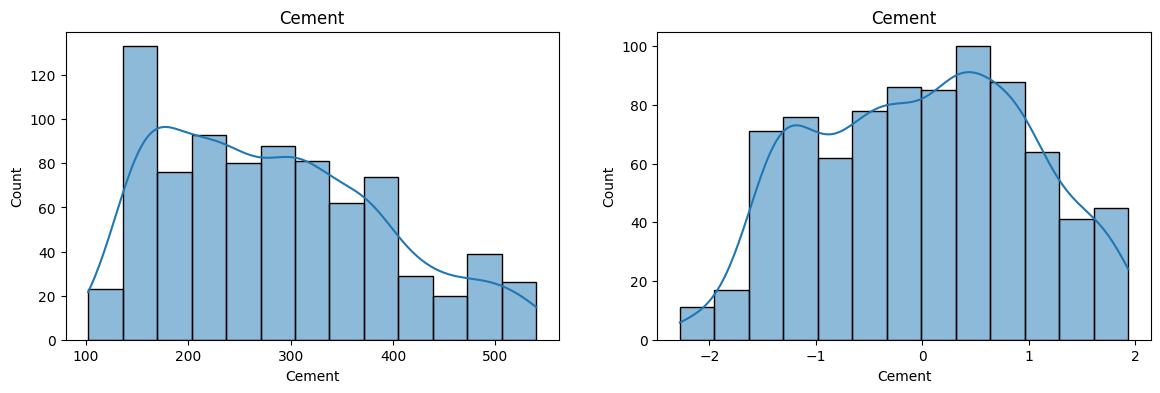

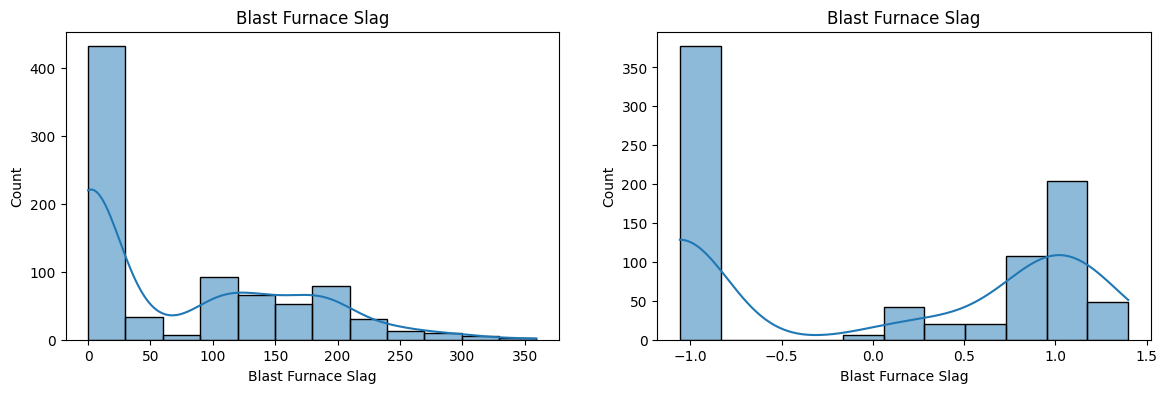

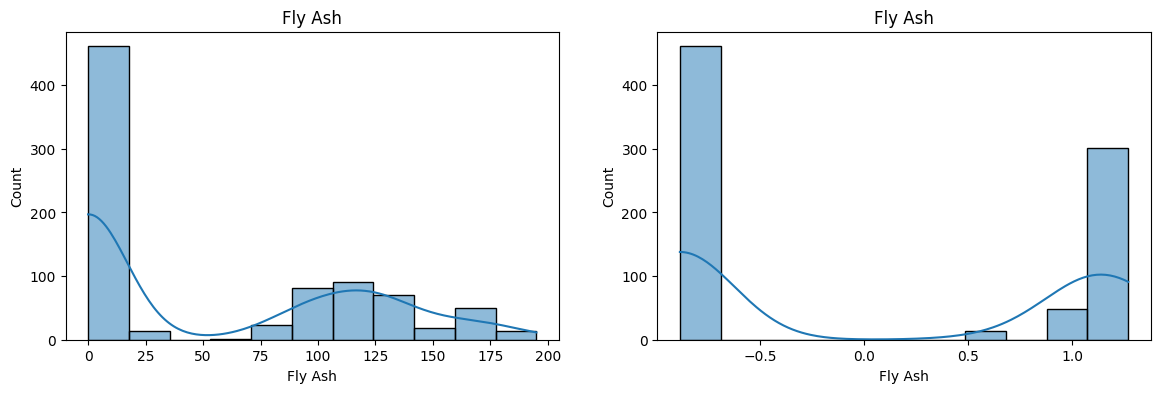

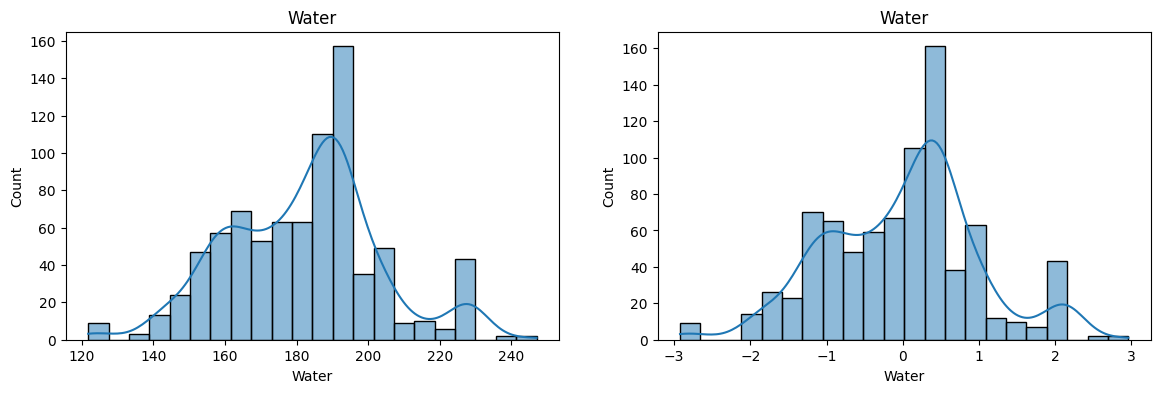

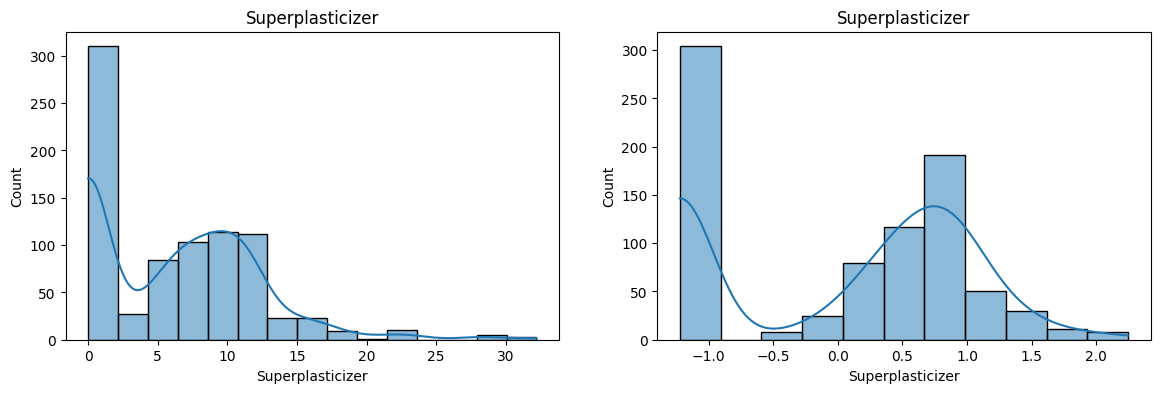

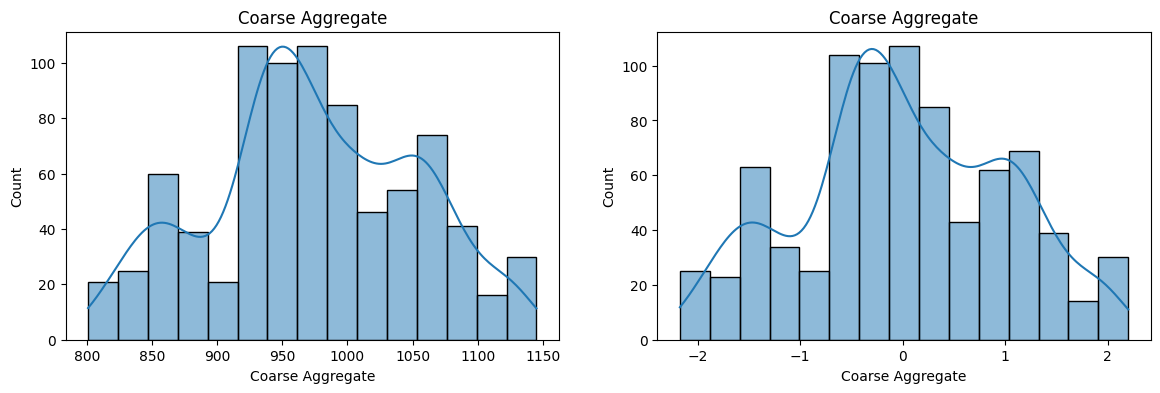

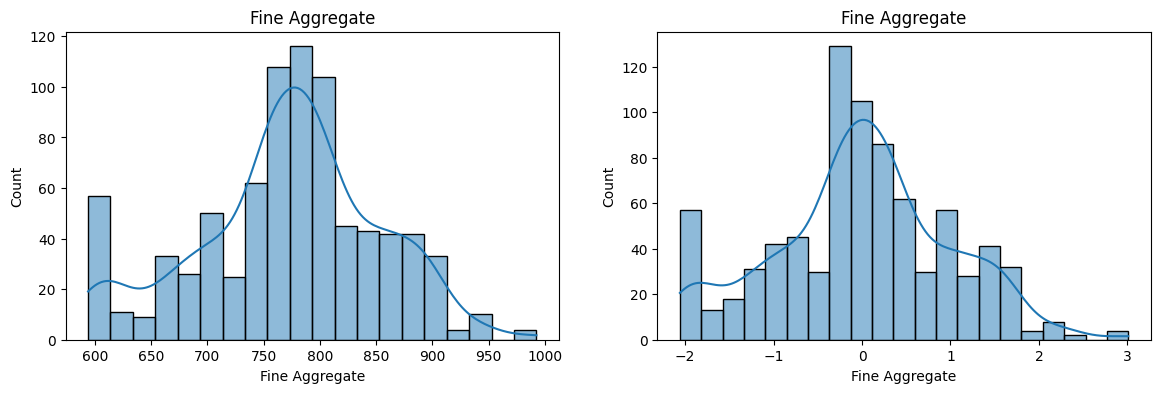

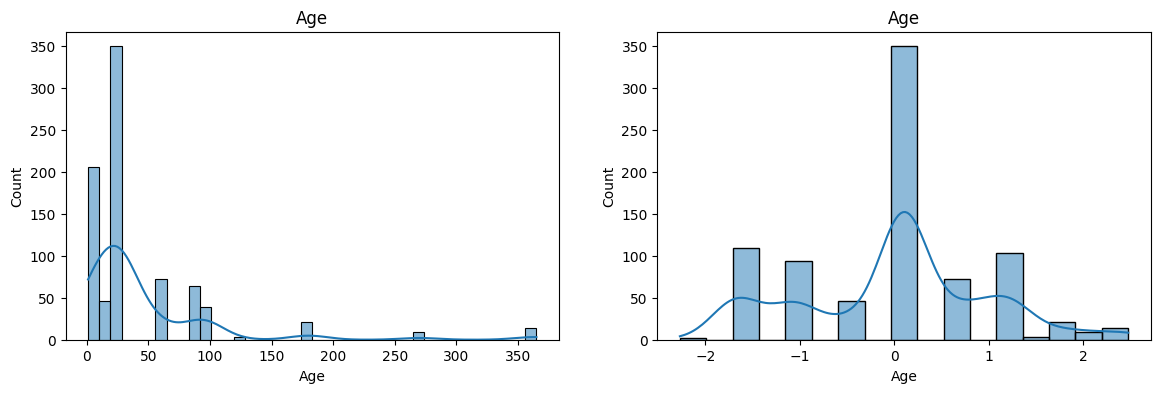

In [94]:
for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col], kde = True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed2[col], kde = True)
    plt.title(col)

    plt.show()

In [95]:
pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.169544,0.213025
1,Blast Furnace Slag,0.016633,0.020476
2,Fly Ash,-0.136480,-0.038218
3,Water,0.808438,0.958936
4,Superplasticizer,0.264160,0.304951
5,Coarse Aggregate,1.129395,1.192751
6,Fine Aggregate,1.830764,1.975085
7,Age,0.001771,-0.062443


In [97]:
lr = LinearRegression()

lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

r2_score(y_test,y_pred)

0.627553179231485

In [98]:
lr = LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring='r2'))

np.float64(0.46099404916628667)